In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import pickle as pkl
from scipy.stats import mannwhitneyu
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler 
plt.style.use('ggplot')
import itertools as it

#suppress runtimewarnings
import warnings 
warnings.filterwarnings("ignore", category=RuntimeWarning)

# EMC feature path and description
feature_path = '/space/gzanardini/tuh_epoched/split/'
feature_list = [file for file in os.listdir(feature_path) if file.endswith('.npy')]
description = pd.read_csv(os.path.join(feature_path, 'description.csv'))
labels = description['epilepsy'].values

# Mann-Whitney U test function
def mann_whitney_u_test(x, y):
    stat, p = mannwhitneyu(x, y, alternative='two-sided')
    return p

def handle_complex_numbers(features):
    if isinstance(features, pd.DataFrame):
        for column in features.columns:
            if np.iscomplexobj(features[column]):
                features[column] = features[column].apply(np.abs)
            features[column].replace([np.inf, -np.inf], np.nan, inplace=True)
    elif isinstance(features, np.ndarray):
        if np.iscomplexobj(features):
            features = np.abs(features)
        features[~np.isfinite(features)] = np.nan
    return features

# Sort the feature list
feature_list.sort()

feature_names = ['cc', 'cwt', 'dwt', 'gcc', 'gplv', 'plv', 'mst', 'sst', 'spectral', 'utm']
combiners=['mean', 'median', 'std', 'skew','kurt']
montages = ['CAR', 'BipolarDB','Cz','Laplacian']
segment_lengths=[1,2,5,10]

feature_dict = {}
for feature in feature_names:
    feature_dict[feature] = [f for f in feature_list if f.startswith(feature)]

0 CAR 1 mean
1 CAR 1 median
2 CAR 1 std
3 CAR 1 skew
4 CAR 1 kurt
5 CAR 2 mean
6 CAR 2 median
7 CAR 2 std
8 CAR 2 skew
9 CAR 2 kurt
10 CAR 5 mean
11 CAR 5 median
12 CAR 5 std
13 CAR 5 skew
14 CAR 5 kurt
15 CAR 10 mean
16 CAR 10 median
17 CAR 10 std
18 CAR 10 skew
19 CAR 10 kurt
20 BipolarDB 1 mean
21 BipolarDB 1 median
22 BipolarDB 1 std
23 BipolarDB 1 skew
24 BipolarDB 1 kurt
25 BipolarDB 2 mean
26 BipolarDB 2 median
27 BipolarDB 2 std
28 BipolarDB 2 skew
29 BipolarDB 2 kurt
30 BipolarDB 5 mean
31 BipolarDB 5 median
32 BipolarDB 5 std
33 BipolarDB 5 skew
34 BipolarDB 5 kurt
35 BipolarDB 10 mean
36 BipolarDB 10 median
37 BipolarDB 10 std
38 BipolarDB 10 skew
39 BipolarDB 10 kurt
40 Cz 1 mean
41 Cz 1 median
42 Cz 1 std
43 Cz 1 skew
44 Cz 1 kurt
45 Cz 2 mean
46 Cz 2 median
47 Cz 2 std
48 Cz 2 skew
49 Cz 2 kurt
50 Cz 5 mean
51 Cz 5 median
52 Cz 5 std
53 Cz 5 skew
54 Cz 5 kurt
55 Cz 10 mean
56 Cz 10 median
57 Cz 10 std
58 Cz 10 skew
59 Cz 10 kurt
60 Laplacian 1 mean
61 Laplacian 1 median
6

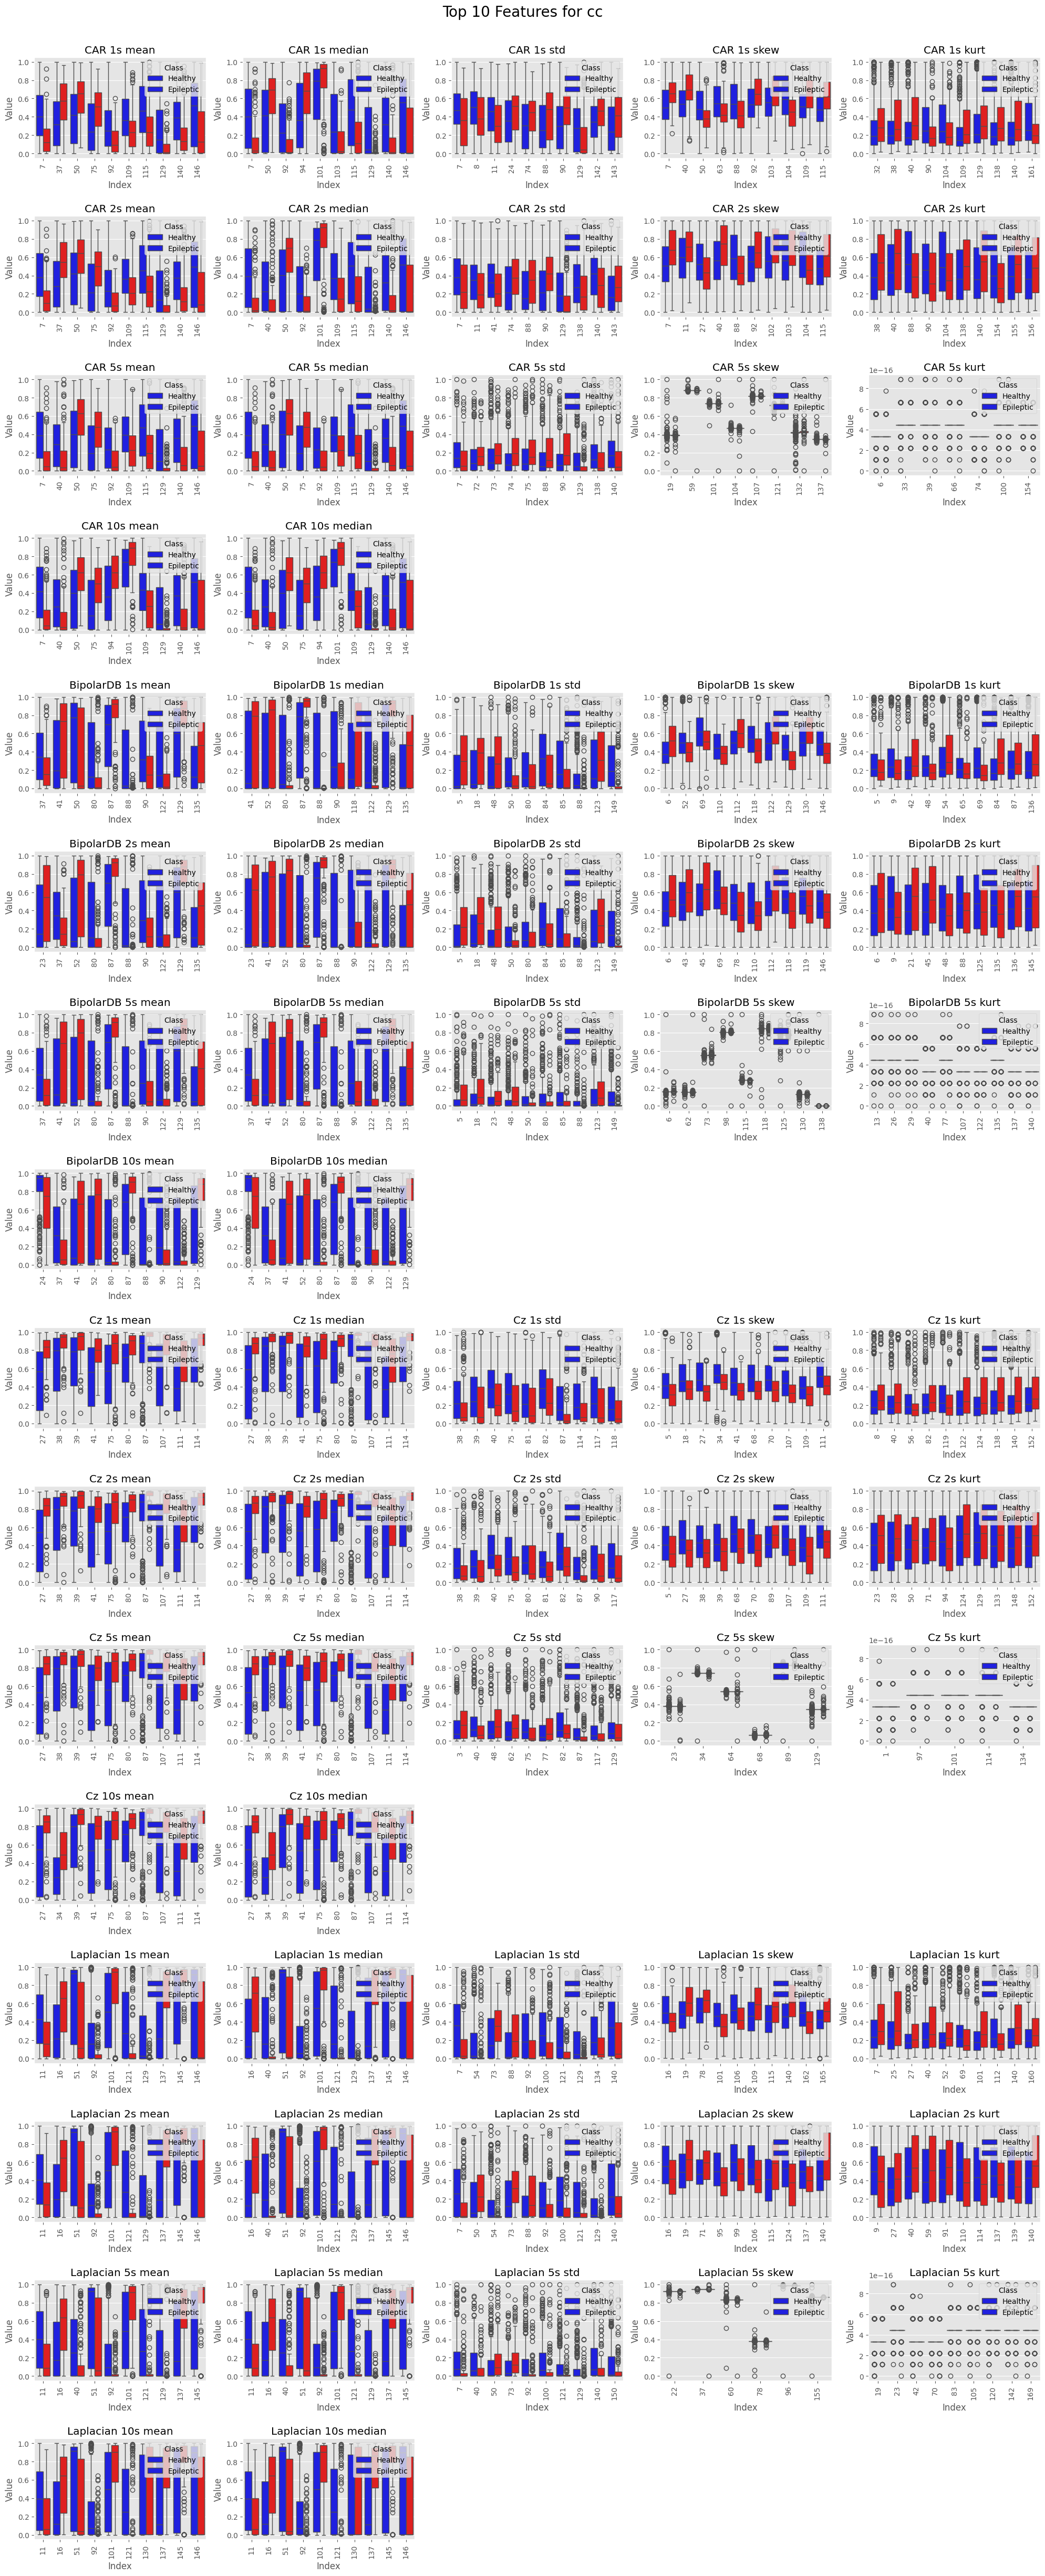

0 CAR 1 mean
1 CAR 1 median
2 CAR 1 std
3 CAR 1 skew
4 CAR 1 kurt
5 CAR 2 mean
6 CAR 2 median
7 CAR 2 std
8 CAR 2 skew
9 CAR 2 kurt
10 CAR 5 mean
11 CAR 5 median
12 CAR 5 std
13 CAR 5 skew
14 CAR 5 kurt
15 CAR 10 mean
16 CAR 10 median
17 CAR 10 std
18 CAR 10 skew
19 CAR 10 kurt
20 BipolarDB 1 mean
21 BipolarDB 1 median
22 BipolarDB 1 std
23 BipolarDB 1 skew
24 BipolarDB 1 kurt
25 BipolarDB 2 mean
26 BipolarDB 2 median
27 BipolarDB 2 std
28 BipolarDB 2 skew
29 BipolarDB 2 kurt
30 BipolarDB 5 mean
31 BipolarDB 5 median
32 BipolarDB 5 std
33 BipolarDB 5 skew
34 BipolarDB 5 kurt
35 BipolarDB 10 mean
36 BipolarDB 10 median
37 BipolarDB 10 std
38 BipolarDB 10 skew
39 BipolarDB 10 kurt
40 Cz 1 mean
41 Cz 1 median
42 Cz 1 std
43 Cz 1 skew
44 Cz 1 kurt
45 Cz 2 mean
46 Cz 2 median
47 Cz 2 std
48 Cz 2 skew
49 Cz 2 kurt
50 Cz 5 mean
51 Cz 5 median
52 Cz 5 std
53 Cz 5 skew
54 Cz 5 kurt
55 Cz 10 mean
56 Cz 10 median
57 Cz 10 std
58 Cz 10 skew
59 Cz 10 kurt
60 Laplacian 1 mean
61 Laplacian 1 median
6

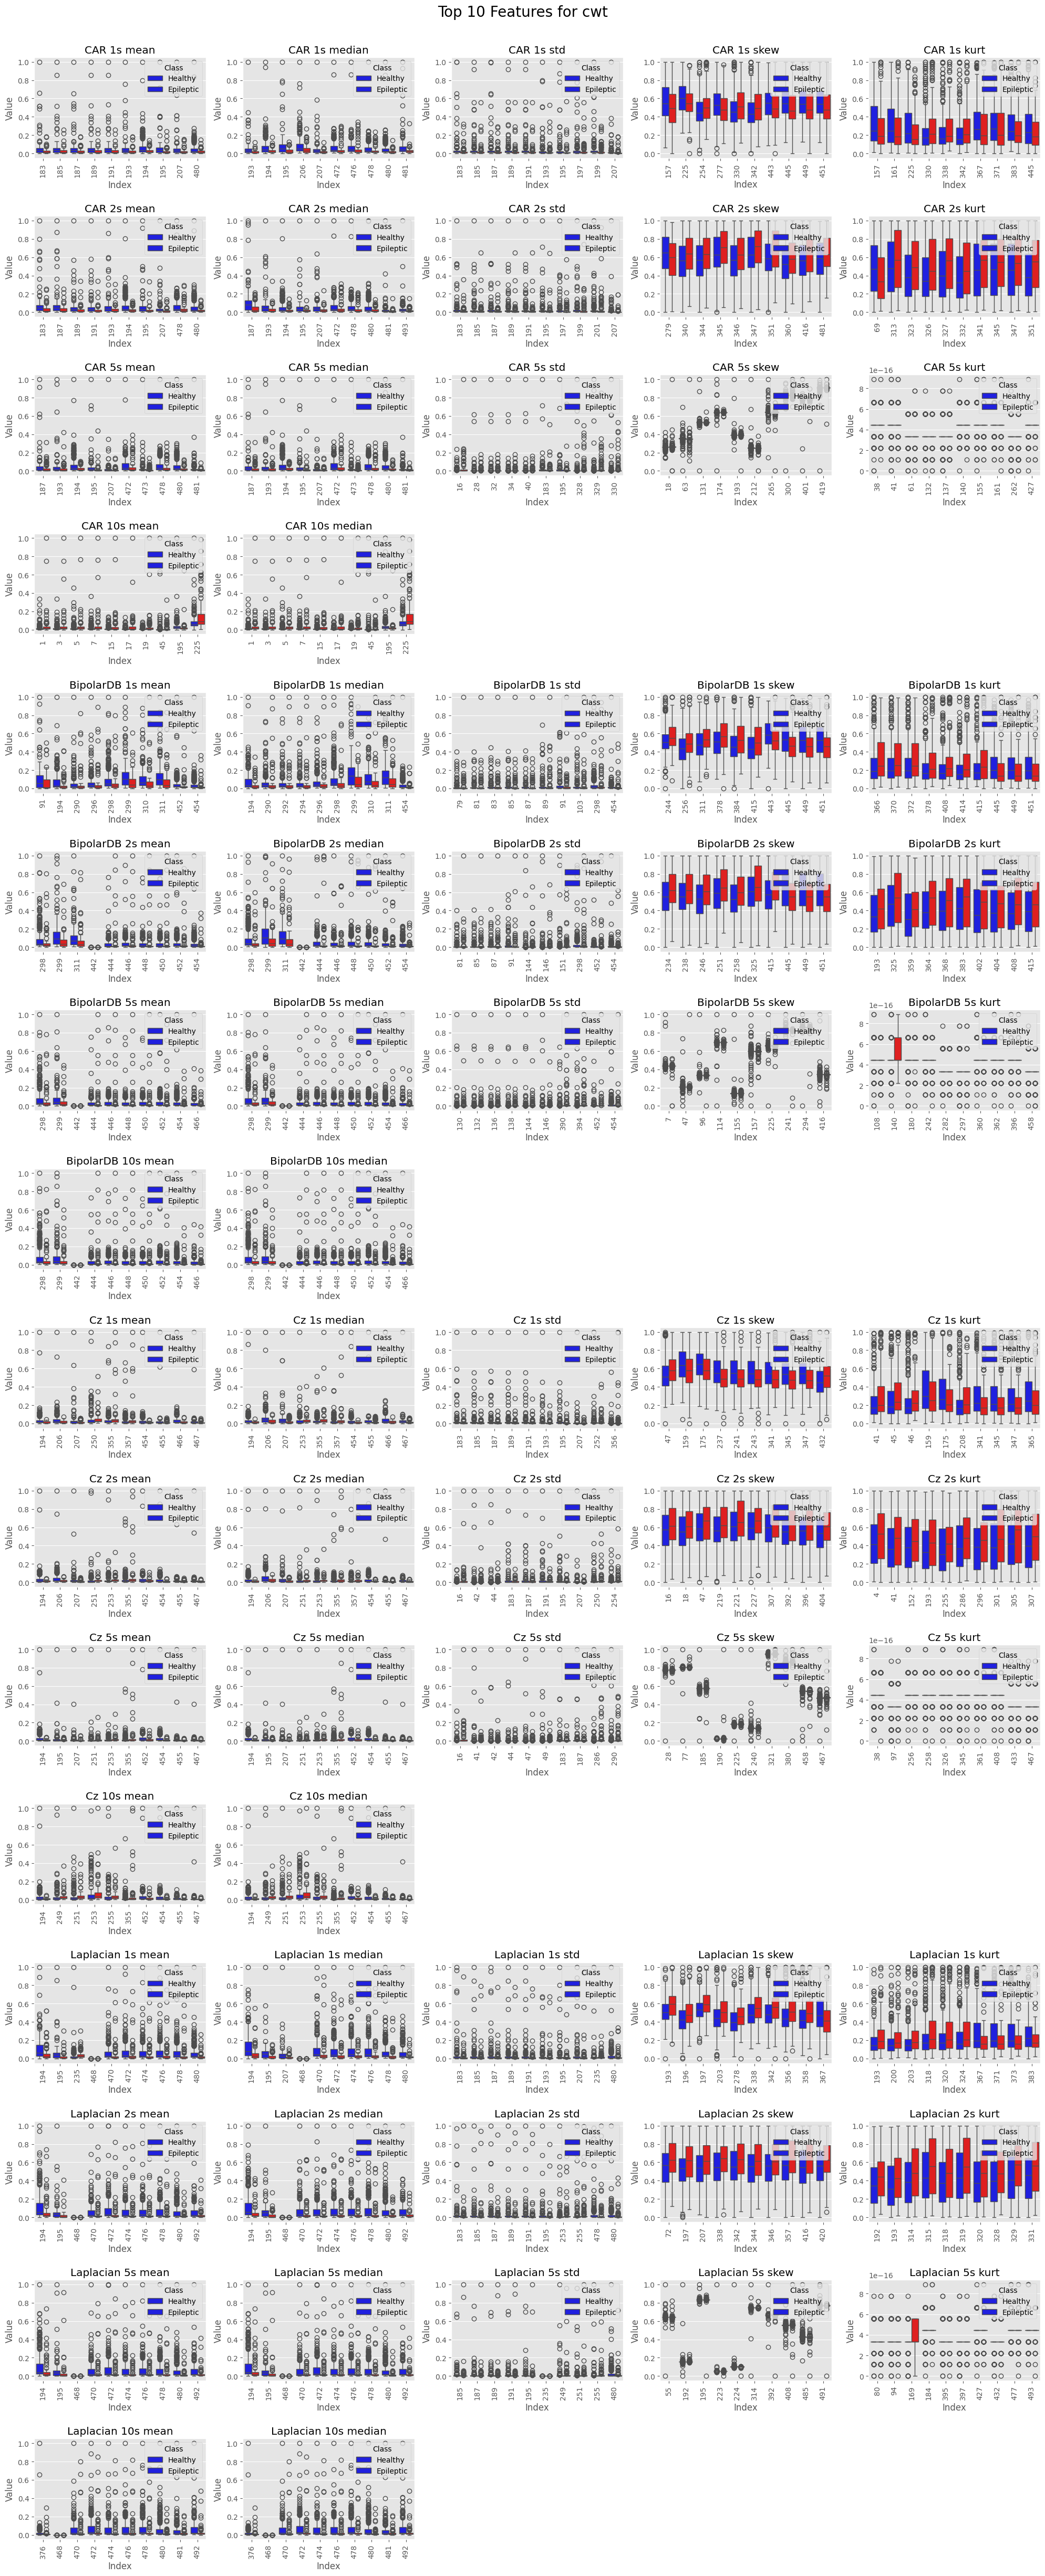

0 CAR 1 mean
1 CAR 1 median
2 CAR 1 std
3 CAR 1 skew
4 CAR 1 kurt
5 CAR 2 mean
6 CAR 2 median
7 CAR 2 std
8 CAR 2 skew
9 CAR 2 kurt
10 CAR 5 mean
11 CAR 5 median
12 CAR 5 std
13 CAR 5 skew
14 CAR 5 kurt
15 CAR 10 mean
16 CAR 10 median
17 CAR 10 std
18 CAR 10 skew
19 CAR 10 kurt
20 BipolarDB 1 mean
21 BipolarDB 1 median
22 BipolarDB 1 std
23 BipolarDB 1 skew
24 BipolarDB 1 kurt
25 BipolarDB 2 mean
26 BipolarDB 2 median
27 BipolarDB 2 std
28 BipolarDB 2 skew
29 BipolarDB 2 kurt
30 BipolarDB 5 mean
31 BipolarDB 5 median
32 BipolarDB 5 std
33 BipolarDB 5 skew
34 BipolarDB 5 kurt
35 BipolarDB 10 mean
36 BipolarDB 10 median
37 BipolarDB 10 std
38 BipolarDB 10 skew
39 BipolarDB 10 kurt
40 Cz 1 mean
41 Cz 1 median
42 Cz 1 std
43 Cz 1 skew
44 Cz 1 kurt
45 Cz 2 mean
46 Cz 2 median
47 Cz 2 std
48 Cz 2 skew
49 Cz 2 kurt
50 Cz 5 mean
51 Cz 5 median
52 Cz 5 std
53 Cz 5 skew
54 Cz 5 kurt
55 Cz 10 mean
56 Cz 10 median
57 Cz 10 std
58 Cz 10 skew
59 Cz 10 kurt
60 Laplacian 1 mean
61 Laplacian 1 median
6

In [ ]:
lowest_pval_df = pd.DataFrame(columns=["Montage", "SegLength", 'Combiner', 'Feature Index', "LowestPValue"], index=feature_names)

for feature in feature_names:
    lowest_pval_df.loc[feature, :] = [None, None, None, None, np.inf]
    plt.figure(figsize=(20, 50))
    plt.suptitle(f"Feature: {feature}", fontsize=16)

    for idx, (montage, segment_length, combiner) in enumerate(it.product(montages, segment_lengths, combiners)):
        print(idx, montage, segment_length, combiner)
        feature_file = f"{feature}_{montage}_{segment_length}s_{combiner}.npy"
        features = np.load(os.path.join(feature_path, feature_file), allow_pickle=True)
        features = handle_complex_numbers(features)

        scaler= MinMaxScaler()
        features = scaler.fit_transform(features)

        ps=np.array([mann_whitney_u_test(features[labels==0][:, i], features[labels==1][:, i]) for i in range(features.shape[1])])
        lowest_indices = np.where(ps < 0.05)[0]
        lowest_indices_sorted = lowest_indices[np.argsort(ps[lowest_indices])]
        lowest_10 = lowest_indices_sorted[:10]

        temp_data = []
        for i in lowest_10:
            for label_class in [0,1]:
                for val in features[labels==label_class][:, i]:
                    temp_data.append({"FeatureIndex": i, "Value": val, "Class": label_class})
        # Update the lowest p-value DataFrame
        if len(lowest_indices) > 0 and min(ps[lowest_indices]) < lowest_pval_df.loc[feature, 'LowestPValue']:
            lowest_pval_df.loc[feature, 'Montage'] = montage
            lowest_pval_df.loc[feature, 'SegLength'] = segment_length
            lowest_pval_df.loc[feature, 'Combiner'] = combiner
            lowest_pval_df.loc[feature, 'Feature Index'] = lowest_indices_sorted[0]
            lowest_pval_df.loc[feature, 'LowestPValue'] = ps[lowest_indices_sorted[0]]
        df = pd.DataFrame(temp_data)
        if not df.empty:
            df['Class'] = df['Class'].map({0: 'Healthy', 1: 'Epileptic'})
            plt.subplot(16,5,idx+1)
            sns.boxplot(x="FeatureIndex", y="Value", hue="Class", data=df, hue_order=['Healthy','Epileptic'], palette=['blue','red'])
            plt.title(f"{montage} {segment_length}s {combiner}")
            plt.xticks(rotation=90)
            plt.legend(title='Class', loc='upper right', labels=['Healthy', 'Epileptic'])
            plt.xlabel('Index')
            plt.ylabel('Value')
    plt.suptitle(f"Top 10 Features for {feature}", fontsize=20)
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()

In [ ]:
lowest_pval_df

,Montage,SegLength,Combiner,Feature Index,LowestPValue
cc,Cz,1,median,87,0.0
cwt,Laplacian,2,median,480,0.0
dwt,Laplacian,10,mean,238,0.0
gcc,Cz,10,mean,6,0.0
gplv,Cz,1,mean,15,0.000699
plv,Cz,1,median,87,0.0
mst,BipolarDB,1,mean,104,0.0
sst,BipolarDB,5,std,11,0.000047
spectral,BipolarDB,2,mean,49,0.0
utm,Laplacian,1,mean,117,0.0
